**Libraries Import**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

**Dataset Load**

In [2]:
df = pd.read_excel('/content/Online_Retail_1200.xlsx')

**First 10 Rows**

In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,INV00001,P011,Diary,2,2025-01-13 23:00:00,200,10141,UK
1,INV00002,P004,Backpack,3,2025-02-22 21:00:00,900,10380,Germany
2,INV00003,P002,Pen Set,10,2025-08-05 01:00:00,80,10016,India
3,INV00004,P004,Backpack,4,2025-09-16 19:00:00,900,10014,Germany
4,INV00005,P004,Backpack,12,2025-11-29 22:00:00,900,10280,Canada
5,INV00006,P004,Backpack,8,2025-10-29 08:00:00,900,10415,Australia
6,INV00007,P001,Notebook,13,2025-03-23 22:00:00,120,10217,USA
7,INV00008,P005,Calculator,3,2025-04-21 10:00:00,450,10053,India
8,INV00009,P007,Mouse,2,2025-07-03 11:00:00,550,10310,USA
9,INV00010,P013,File Folder,1,2025-08-24 17:00:00,90,10064,Canada


**Dataset Size**

In [4]:
df.shape

(1200, 8)

**Dataset Information**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    1200 non-null   object        
 1   StockCode    1200 non-null   object        
 2   Description  1200 non-null   object        
 3   Quantity     1200 non-null   int64         
 4   InvoiceDate  1200 non-null   datetime64[ns]
 5   UnitPrice    1200 non-null   int64         
 6   CustomerID   1200 non-null   int64         
 7   Country      1200 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(4)
memory usage: 75.1+ KB


**Columns ke Name**

In [6]:
import os

os.listdir('/content')

['.config', 'Online_Retail_1200.xlsx', 'sample_data']

In [7]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

**Missing Values**

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


**Duplicate Rows**

In [9]:
df.duplicated().sum()

np.int64(0)

**Statistical Summary**

In [10]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,1200.000000,1200,1200.000000,1200.000000
mean,8.108333,2025-07-05 12:17:03.000000256,424.050000,10252.350000
min,1.000000,2025-01-01 01:00:00,80.000000,10001.000000
25%,4.000000,2025-03-30 11:45:00,130.000000,10130.500000
50%,8.000000,2025-07-08 12:00:00,250.000000,10255.000000
75%,12.000000,2025-10-04 23:30:00,700.000000,10372.500000
max,15.000000,2025-12-31 23:00:00,1200.000000,10499.000000
std,4.256959,NaN,346.232333,144.569283


**Data Types**

In [11]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,int64
CustomerID,int64
Country,object


**Total Amount**

In [12]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,INV00001,P011,Diary,2,2025-01-13 23:00:00,200,10141,UK,400
1,INV00002,P004,Backpack,3,2025-02-22 21:00:00,900,10380,Germany,2700
2,INV00003,P002,Pen Set,10,2025-08-05 01:00:00,80,10016,India,800
3,INV00004,P004,Backpack,4,2025-09-16 19:00:00,900,10014,Germany,3600
4,INV00005,P004,Backpack,12,2025-11-29 22:00:00,900,10280,Canada,10800


**Customer-wise Statistics**

In [13]:
customer_stats = df.groupby('CustomerID').agg(
    Total_Spending=('TotalAmount', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Transactions=('InvoiceNo', 'nunique')
).reset_index()
customer_stats.head(10)

,CustomerID,Total_Spending,Total_Quantity,Number_of_Transactions
0,10001,2800,16,2
1,10002,3310,9,2
2,10003,8400,15,3
3,10004,15220,35,3
4,10005,10950,43,4
5,10006,1440,12,1
6,10007,1200,6,1
7,10008,880,11,1
8,10009,9810,34,6
9,10010,1560,12,1


**Features Select**

In [14]:
features = customer_stats[
    ['Total_Spending', 'Total_Quantity', 'Number_of_Transactions']
]

features.head()

,Total_Spending,Total_Quantity,Number_of_Transactions
0,2800,16,2
1,3310,9,2
2,8400,15,3
3,15220,35,3
4,10950,43,4


**Check Features**

In [15]:
features.shape

(449, 3)

**Data StandardizationData Standardization**

In [16]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,INV00001,P011,Diary,2,2025-01-13 23:00:00,200,10141,UK,400
1,INV00002,P004,Backpack,3,2025-02-22 21:00:00,900,10380,Germany,2700
2,INV00003,P002,Pen Set,10,2025-08-05 01:00:00,80,10016,India,800
3,INV00004,P004,Backpack,4,2025-09-16 19:00:00,900,10014,Germany,3600
4,INV00005,P004,Backpack,12,2025-11-29 22:00:00,900,10280,Canada,10800


**Check Result**

In [17]:
scaled_features[:5]

array([[-0.87670154, -0.44725915, -0.48802445],
       [-0.80672688, -0.99939407, -0.48802445],
       [-0.10835239, -0.52613557,  0.23754832],
       [ 0.82738711,  1.05139278,  0.23754832],
       [ 0.24152089,  1.68240412,  0.96312109]])

**Elbow Method**

In [18]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

**Elbow Graph**

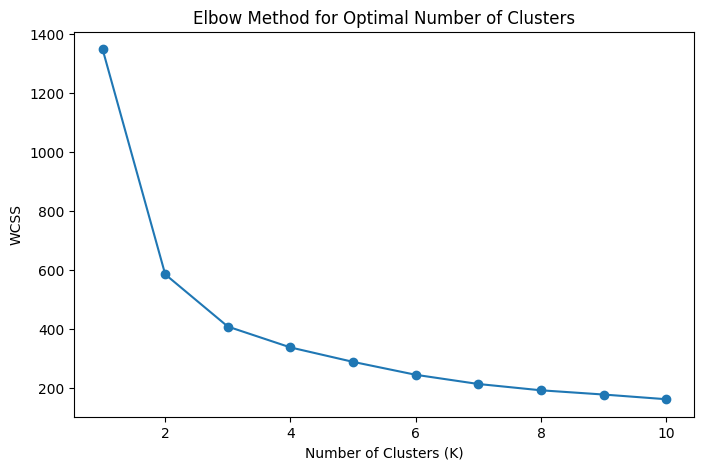

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

**K-Means Clustering**

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_stats['Cluster'] = kmeans.fit_predict(scaled_features)
customer_stats.head(10)

,CustomerID,Total_Spending,Total_Quantity,Number_of_Transactions,Cluster
0,10001,2800,16,2,1
1,10002,3310,9,2,1
2,10003,8400,15,3,2
3,10004,15220,35,3,2
4,10005,10950,43,4,0
5,10006,1440,12,1,1
6,10007,1200,6,1,1
7,10008,880,11,1,1
8,10009,9810,34,6,0
9,10010,1560,12,1,1


**Customers in Clusters**

In [21]:
cluster_counts = customer_stats['Cluster'].value_counts().sort_index()
cluster_counts

,count
Cluster,
0,90
1,191
2,168


**Customer Count Bar Chart**

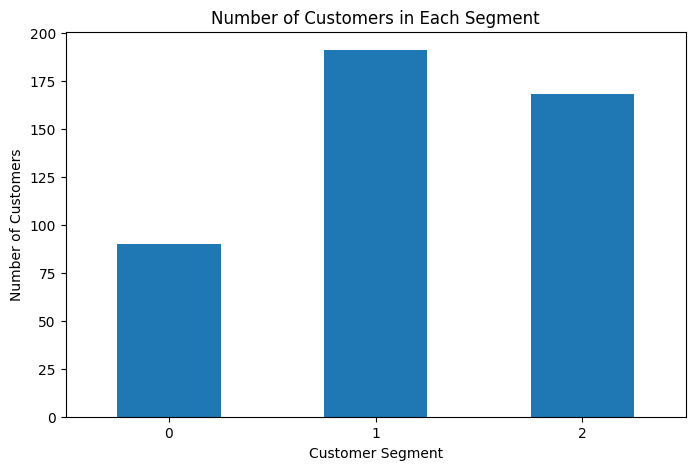

In [22]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

**Segment Profile**

In [23]:
cluster_profile = customer_stats.groupby('Cluster')[
    ['Total_Spending', 'Total_Quantity', 'Number_of_Transactions']
].mean().round(2)

cluster_profile

,Total_Spending,Total_Quantity,Number_of_Transactions
Cluster,,,
0,19300.78,40.41,4.62
1,3687.91,10.84,1.54
2,10028.10,23.94,2.92


**Scatter Plot**

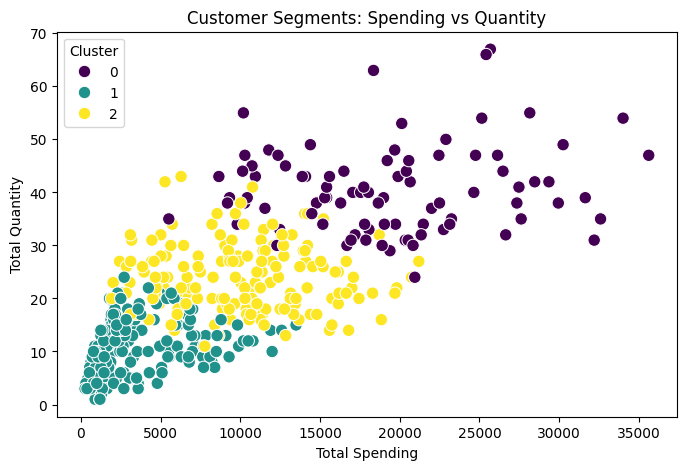

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=customer_stats,
    x='Total_Spending',
    y='Total_Quantity',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segments: Spending vs Quantity')
plt.xlabel('Total Spending')
plt.ylabel('Total Quantity')
plt.legend(title='Cluster')
plt.show()

**Second Scatter Plot**

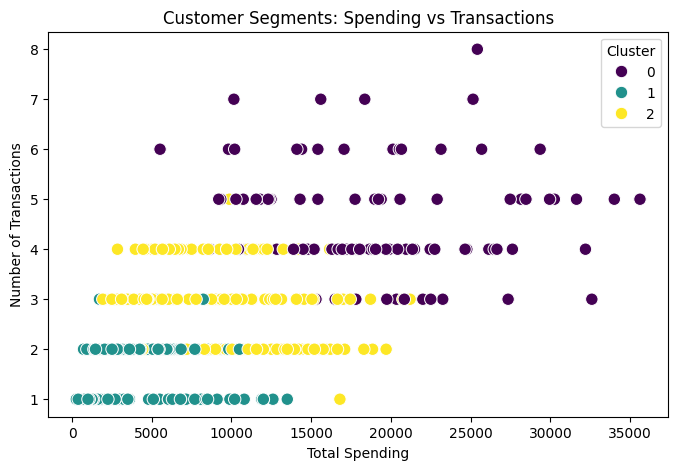

In [25]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=customer_stats,
    x='Total_Spending',
    y='Number_of_Transactions',
    hue='Cluster',
    palette='viridis',
    s=80
)

plt.title('Customer Segments: Spending vs Transactions')
plt.xlabel('Total Spending')
plt.ylabel('Number of Transactions')
plt.legend(title='Cluster')
plt.show()

**Cluster-wise Customer Count**

In [26]:
cluster_counts = customer_stats['Cluster'].value_counts().sort_index()
cluster_counts

,count
Cluster,
0,90
1,191
2,168


**Customer Count Bar Chart**

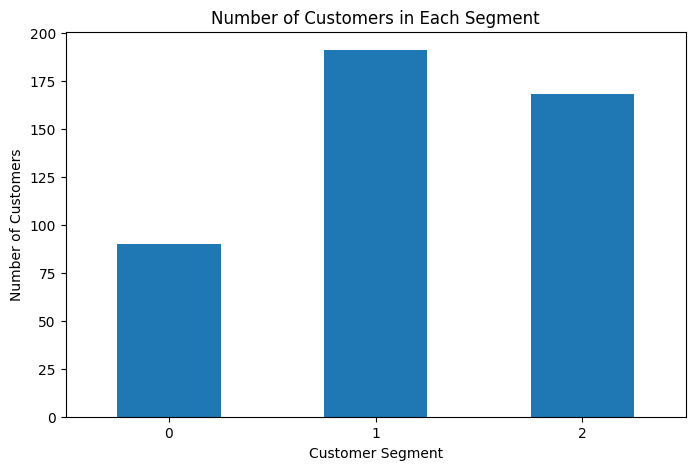

In [27]:
plt.figure(figsize=(8, 5))

cluster_counts.plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

**Segment Profile**

In [28]:
cluster_profile = customer_stats.groupby('Cluster')[
    ['Total_Spending', 'Total_Quantity', 'Number_of_Transactions']
].mean().round(2)

cluster_profile

,Total_Spending,Total_Quantity,Number_of_Transactions
Cluster,,,
0,19300.78,40.41,4.62
1,3687.91,10.84,1.54
2,10028.10,23.94,2.92


**Final Cluster Summary**

In [29]:
cluster_summary = customer_stats.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    Avg_Spending=('Total_Spending', 'mean'),
    Avg_Quantity=('Total_Quantity', 'mean'),
    Avg_Transactions=('Number_of_Transactions', 'mean')
).round(2)

cluster_summary

,Customers,Avg_Spending,Avg_Quantity,Avg_Transactions
Cluster,,,,
0,90,19300.78,40.41,4.62
1,191,3687.91,10.84,1.54
2,168,10028.10,23.94,2.92


**Segment Names Add Karna**

In [30]:
cluster_names = {
    0: 'High-Value Customers',
    1: 'Low-Value Customers',
    2: 'Medium-Value Customers'
}

customer_stats['Segment'] = customer_stats['Cluster'].map(cluster_names)

customer_stats.head(10)

,CustomerID,Total_Spending,Total_Quantity,Number_of_Transactions,Cluster,Segment
0,10001,2800,16,2,1,Low-Value Customers
1,10002,3310,9,2,1,Low-Value Customers
2,10003,8400,15,3,2,Medium-Value Customers
3,10004,15220,35,3,2,Medium-Value Customers
4,10005,10950,43,4,0,High-Value Customers
5,10006,1440,12,1,1,Low-Value Customers
6,10007,1200,6,1,1,Low-Value Customers
7,10008,880,11,1,1,Low-Value Customers
8,10009,9810,34,6,0,High-Value Customers
9,10010,1560,12,1,1,Low-Value Customers


**Segment-wise Customer Count**

In [31]:
segment_counts = customer_stats['Segment'].value_counts()
segment_counts

,count
Segment,
Low-Value Customers,191
Medium-Value Customers,168
High-Value Customers,90


**Final Segment Bar Chart**

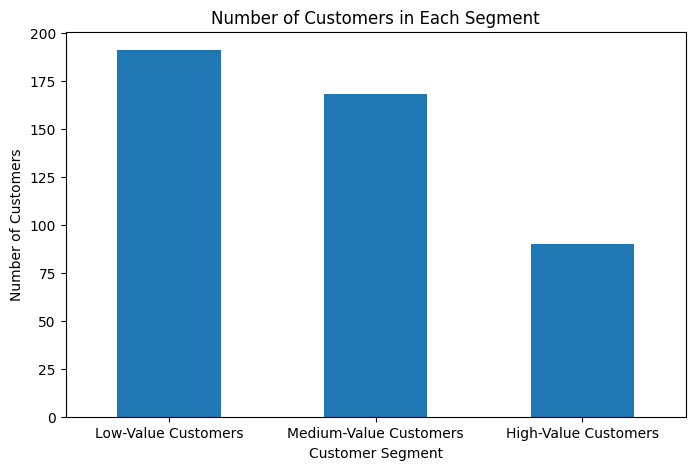

In [32]:
plt.figure(figsize=(8, 5))

segment_counts.plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

**Marketing Recommendations**

**1. High-Value Customers**

I)Provide loyalty rewards and exclusive offers.

II)Give personalized product recommendations.

III)Encourage repeat purchases through loyalty programs.

2.Medium-Value Customers

I)Offer targeted discounts to increase spending.

II)Recommend related products and bundles.

III)Encourage customers to purchase more frequently.

**3. Low-Value Customers**

I)Provide attractive offers to encourage repeat purchases.

II)Recommend affordable products and useful bundles.

III)Use personalized promotions to increase engagement.

**Final Interpretation.**

The K-Means clustering analysis divided 449 customers into three distinct segments based on their purchasing behaviour. Cluster 0 contains 90 high-value customers with the highest average spending of 19,300.78, average quantity of 40.41, and 4.62 transactions. Cluster 1 is the largest segment with 191 low-value customers, showing the lowest average spending of 3,687.91, quantity of 10.84, and 1.54 transactions. Cluster 2 contains 168 medium-value customers with moderate spending of 10,028.10, quantity of 23.94, and 2.92 transactions. These segments help identify different customer purchasing patterns and can be used to create targeted marketing strategies.

**Conclusion**

Customer segmentation using K-Means clustering successfully grouped customers according to their purchasing behaviour. The analysis identified high-value, medium-value, and low-value customer segments. These insights can help businesses design personalized marketing campaigns, improve customer engagement, and focus their strategies on different customer groups.